In [1]:
import os
from pathlib import Path

# Good vs Bad Component Classifier (Local)

Transfer-learning based binary classifier (good vs bad) on the combined metal_nut + screw dataset.

Run this from inside the project folder — `combined_dataset/good` and `combined_dataset/bad` should sit next to this notebook.

In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPU available: []


Confirms whether a GPU is available locally. If it prints an empty list, training will still work on CPU, just slower.

In [3]:
from pathlib import Path
data_dir=Path('combined_dataset')
if not data_dir.exists():
    alt=Path('/mnt/data/combined_dataset')
    if alt.exists():
        data_dir=alt
    else:
        raise FileNotFoundError(f'Could not find dataset folder: {data_dir}')
print(os.listdir(data_dir))

['bad', 'good']


Points to the local `combined_dataset` folder, which should contain `good` and `bad` subfolders.

In [4]:
img_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 815 files belonging to 2 classes.
Using 652 files for training.
Found 815 files belonging to 2 classes.
Using 163 files for validation.
['bad', 'good']


224x224 is used because the model below (MobileNetV2) is pretrained on ImageNet at that resolution. Labels come from folder names, so `bad` = 0, `good` = 1.

In [5]:
import numpy as np

labels = np.concatenate([y.numpy() for _, y in train_ds])
counts = np.bincount(labels)
print("bad:", counts[0], "good:", counts[1])

total = counts.sum()
class_weight = {
    0: total / (2 * counts[0]),
    1: total / (2 * counts[1])
}
print("class weights:", class_weight)

bad: 167 good: 485
class weights: {0: np.float64(1.9520958083832336), 1: np.float64(0.6721649484536083)}


The dataset is imbalanced (more good than bad). Class weights are computed here and passed into training so the model doesn't just learn to predict "good" every time and still score high accuracy.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Data augmentation (flips, rotation, zoom, contrast) is applied only to the training set. This matters a lot here because the dataset is small (~800 images) — augmentation reduces overfitting and improves generalisation to real defect variations. The validation set is left untouched so accuracy numbers stay honest.

In [7]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze for the first training phase

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Instead of a small CNN trained from scratch, this uses MobileNetV2 pretrained on ImageNet as a frozen feature extractor, with a small classification head on top. Transfer learning gives much better accuracy than training from scratch on a dataset this size (~800 images).

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

EarlyStopping stops training once validation loss stops improving and restores the best-performing weights. ReduceLROnPlateau lowers the learning rate when progress stalls, which usually squeezes out extra accuracy in the final epochs.

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/25


c:\Users\Harsidh Chellaiah\Downloads\component_classifier_local\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


21/21 ━━━━━━━━━━━━━━━━━━━━ 25s 629ms/step - accuracy: 0.5706 - loss: 0.7954 - val_accuracy: 0.3804 - val_loss: 0.8023 - learning_rate: 0.0010
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step - accuracy: 0.5552 - loss: 0.6561 - val_accuracy: 0.7178 - val_loss: 0.5705 - learning_rate: 0.0010
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step - accuracy: 0.6764 - loss: 0.6176 - val_accuracy: 0.8098 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 525ms/step - accuracy: 0.6917 - loss: 0.5910 - val_accuracy: 0.7730 - val_loss: 0.5200 - learning_rate: 0.0010
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 561ms/step - accuracy: 0.7285 - loss: 0.5254 - val_accuracy: 0.7975 - val_loss: 0.5215 - learning_rate: 0.0010
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.7193 - loss: 0.5515 - val_accuracy: 0.5031 - val_loss: 0.7051 - learning_rate: 0.0010
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 488ms/step - accuracy: 0.7454 - loss: 0.5299 - val_

Full training run (phase 1, base model still frozen), using Adam which is a solid default for this kind of transfer-learning setup. Up to 25 epochs, but EarlyStopping will cut it short once validation loss stops improving.

In [10]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 744ms/step - accuracy: 0.7546 - loss: 0.7045 - val_accuracy: 0.7362 - val_loss: 0.5153 - learning_rate: 1.0000e-05
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 636ms/step - accuracy: 0.7699 - loss: 0.5777 - val_accuracy: 0.7301 - val_loss: 0.5231 - learning_rate: 1.0000e-05
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 630ms/step - accuracy: 0.7822 - loss: 0.4949 - val_accuracy: 0.7239 - val_loss: 0.5248 - learning_rate: 1.0000e-05
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 602ms/step - accuracy: 0.8006 - loss: 0.4623 - val_accuracy: 0.7239 - val_loss: 0.5167 - learning_rate: 5.0000e-06
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 582ms/step - accuracy: 0.7945 - loss: 0.4747 - val_accuracy: 0.7423 - val_loss: 0.5043 - learning_rate: 5.0000e-06
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 611ms/step - accuracy: 0.8113 - loss: 0.4377 - val_accuracy: 0.7607 - val_loss: 0.4922 - learning_rate: 5.0000e-06
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 596ms/step - acc

Phase 2: fine-tuning. The last 30 layers of MobileNetV2 are unfrozen and retrained with a much smaller learning rate (1e-5). This lets the model adapt its high-level features specifically to metal nuts/screws instead of generic ImageNet objects, which typically gives a noticeable accuracy boost over the frozen-base model alone.

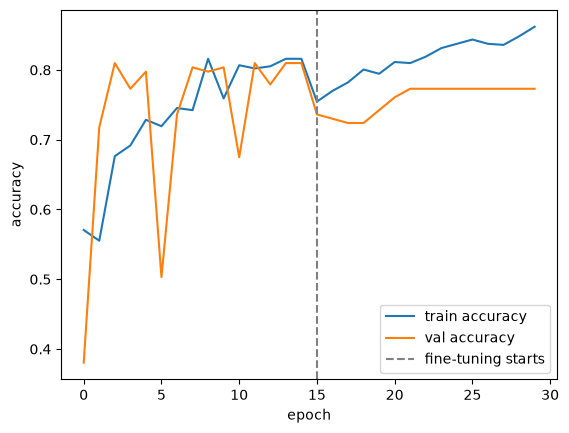

In [11]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]

plt.plot(acc, label="train accuracy")
plt.plot(val_acc, label="val accuracy")
plt.axvline(len(history.history["accuracy"]), color="gray", linestyle="--", label="fine-tuning starts")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

Plots accuracy across both training phases, with a marker showing where fine-tuning began.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_pred_probs = model.predict(val_ds).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=class_names))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 635ms/step
              precision    recall  f1-score   support

         bad       0.63      0.42      0.51        45
        good       0.80      0.91      0.85       118

    accuracy                           0.77       163
   macro avg       0.72      0.66      0.68       163
weighted avg       0.76      0.77      0.76       163

Confusion matrix:
 [[ 19  26]
 [ 11 107]]


Overall accuracy alone can be misleading on an imbalanced dataset. This shows precision/recall/F1 per class plus the confusion matrix, so it's clear whether the model is actually catching bad (defective) components rather than just defaulting to good.

In [13]:
model.save("component_classifier.keras")
print("Saved model to component_classifier.keras")

Saved model to component_classifier.keras


Saves the final fine-tuned model so it can be reloaded later with `tf.keras.models.load_model("component_classifier.keras")` without retraining.